In [14]:
# Bibliotecas para processamento de dados.
import pandas
# Bibliotecas de machine learning.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
# Bibliotecas para construção de gráficos.
import matplotlib.pyplot as pyplot
import seaborn

In [15]:
#Passo 1: Carregamento e Análise dos Dados
arquivo = "diabetes-data.csv"
dados = pandas.read_csv(arquivo,sep=",", decimal = ";")

display(dados.head(15))


,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.50972593,1.213191354,21,0
1,1147438,8,92,93,47,36,21.24057571,0.158364981,23,0
2,1640031,7,115,47,52,35,41.51152348,0.079018568,23,0
3,1883350,9,103,78,25,304,29.58219193,1.282869847,43,1
4,1424119,1,85,59,27,35,42.60453585,0.549541871,22,0
5,1619297,0,82,92,9,253,19.72416021,0.103424498,26,0
6,1660149,0,133,47,19,227,21.94135672,0.174159779,21,0
7,1458769,0,67,87,43,36,18.2777226,0.23616494,26,0
8,1201647,8,80,95,33,24,26.62492885,0.443947388,53,1
9,1403912,1,72,31,40,42,36.88957571,0.103943637,26,0


In [16]:
#Passo 2: Pré-processamento

print(dados.dtypes)
filtrados = dados.dropna(subset=[
    'Pregnancies',
    'PlasmaGlucose',
    'DiastolicBloodPressure',
    'TricepsThickness',
    'SerumInsulin',
    'BMI',
    'DiabetesPedigree',
    'Age',
    'Diabetic'
    
])

PatientID                  int64
Pregnancies                int64
PlasmaGlucose              int64
DiastolicBloodPressure     int64
TricepsThickness           int64
SerumInsulin               int64
BMI                       object
DiabetesPedigree          object
Age                        int64
Diabetic                   int64
dtype: object


In [17]:
# Calcula a quantidade de linhas removidas.
originais = len(dados)
finais = len(filtrados)
eliminados = originais - finais
percentual = (eliminados/originais) * 100
# Exibe o número de linhas originais e removidas.
print(f'Quantidade Original de Dados: {originais}')
print(f"Quantidade de Dados Pós-Filtragem: {eliminados}")
print(f"Percentual de Dados Removidos: {percentual:.2} %")

Quantidade Original de Dados: 10000
Quantidade de Dados Pós-Filtragem: 0
Percentual de Dados Removidos: 0.0 %


In [ ]:
#Passo 3: Separação dos Dados
dadostm,dadosts = train_test_split(filtrados,test_size=0.3,random_state=42)

preditorestm = dadostm[[
    'Pregnancies',
    'PlasmaGlucose',
    'DiastolicBloodPressure',
    'TricepsThickness',
    'SerumInsulin',
    'BMI',
    'DiabetesPedigree',
    'Age'
]]

alvotm= dadostm['Diabetic']

preditorests = dadosts[[
    'Pregnancies',
    'PlasmaGlucose',
    'DiastolicBloodPressure',
    'TricepsThickness',
    'SerumInsulin',
    'BMI',
    'DiabetesPedigree',
    'Age'
]]

alvots= dadosts['Diabetic']

In [ ]:
#Passo 4: Treinamento dos Modelos
modelsvm = SVC(random_state=42)

modelsvm.fit(preditorestm,alvotm)

modelorl = LogisticRegression(max_iter=200,random_state=42)

modelorl.fit(preditorestm,alvotm)



LogisticRegression(max_iter=200, random_state=42)

In [ ]:
#Passo 5: Avaliação dos Modelos
estimativasrl = modelorl.predict(preditorests)
estimativasVm = modelsvm.predict(preditorests)

acuraiarl = accuracy_score(alvots,estimativasrl)
acuraiasvm = accuracy_score(alvots,estimativasVm)

matrizRl = confusion_matrix(alvots, estimativasrl)
matrizvm =confusion_matrix(alvots,estimativasVm)

print(f"acuracia - RL {acuraiarl:.2f}")
print(f"acuracia - VM {acuraiasvm:.2f}")

print(f"matrix de confusao -RL ")
print(matrizRl)
print("machine learning")
print(matrizvm)

acuracia - RL 0.80
acuracia - VM 0.81
matrix de confusao -RL 
[[1814  223]
 [ 389  574]]
machine learning
[[1862  175]
 [ 396  567]]


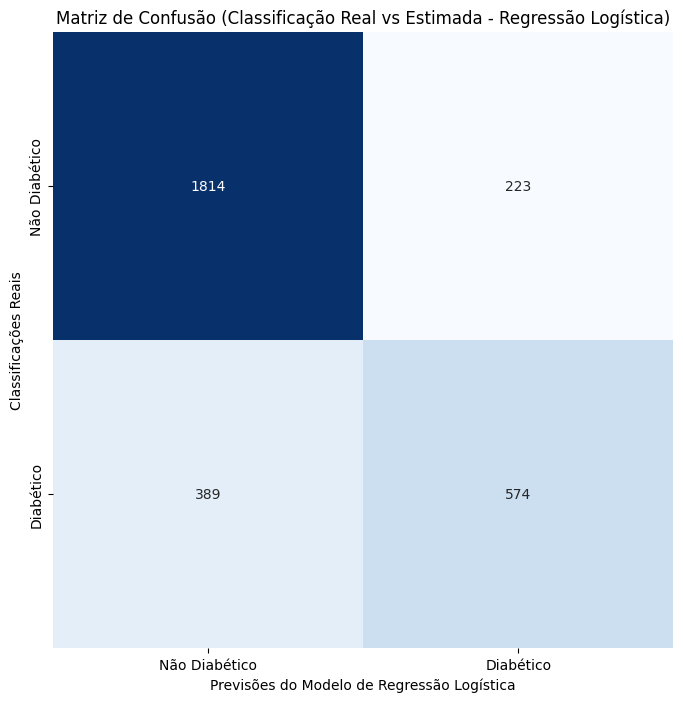

In [28]:
# Construção do gráfico da matriz de confusão da Regressão Logística.
pyplot.figure(figsize=(8, 8))
seaborn.heatmap(matrizRl, annot=True, fmt='d', cmap='Blues', cbar=False,
xticklabels=['Não Diabético', 'Diabético'],
yticklabels=['Não Diabético', 'Diabético'])
pyplot.title('Matriz de Confusão (Classificação Real vs Estimada - Regressão Logística)')
pyplot.xlabel('Previsões do Modelo de Regressão Logística')
pyplot.ylabel('Classificações Reais')
pyplot.show()

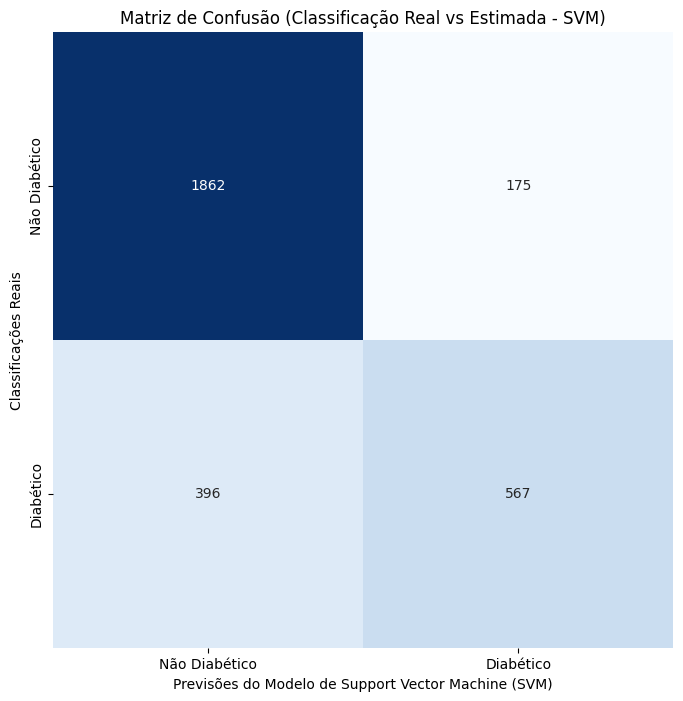

In [22]:
# Construção do gráfico da matriz de confusão do SVM.
pyplot.figure(figsize=(8, 8))
seaborn.heatmap(matrizvm, annot=True, fmt='d', cmap='Blues', cbar=False,
xticklabels=['Não Diabético', 'Diabético'],
yticklabels=['Não Diabético', 'Diabético'])
pyplot.title('Matriz de Confusão (Classificação Real vs Estimada - SVM)')
pyplot.xlabel('Previsões do Modelo de Support Vector Machine (SVM)')
pyplot.ylabel('Classificações Reais')
pyplot.show()

In [23]:
# Entrada manual de um novo paciente.
paciente = pandas.DataFrame({
'Pregnancies': [9],
'PlasmaGlucose': [103],
'DiastolicBloodPressure': [78],
'TricepsThickness': [25],
'SerumInsulin': [304],
'BMI': [29.58219],
'DiabetesPedigree': [1.28287],
'Age': [43]
})

In [24]:
# Escolhe o modelo para previsão (RL ou SVM).
escolha = 'SVM'
# Faz as previsões usando o modelo escolhido.
if escolha == 'SVM':
    estimativa = modelsvm.predict(paciente)
    print(f"Classificação estimada com Support Vector Machine: {estimativa[0]}")
elif escolha == 'RL':
    estimativa = modelorl.predict(paciente)
    print(f"Classificação estimada com Regressão Logística: {estimativa[0]}")

Classificação estimada com Support Vector Machine: 1
